* In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights.

We would answer the following questions

1. Do more restaurants provide online delivery compared to offline services?
2. Which types of resturants are most favored by the general public?
3. What price range do couple prefer for dining out?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('D:/AI/Zomato_data.csv')
df[0:10]

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
5,Timepass Dinner,Yes,No,3.8/5,286,600,Buffet
6,Rosewood International Hotel - Bar & Restaurant,No,No,3.6/5,8,800,Buffet
7,Onesta,Yes,Yes,4.6/5,2556,600,Cafes
8,Penthouse Cafe,Yes,No,4.0/5,324,700,other
9,Smacznego,Yes,No,4.2/5,504,550,Cafes


In [12]:
# Convert the rate column into float values to remove the denominator
def handle_rate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate'] = df['rate'].apply(handle_rate)
# df[0:10]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [ ]:
# Checking for missing values
print(df.isnull().sum())        # There is no null values


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


Text(0.5, 0, 'Types of resturant')

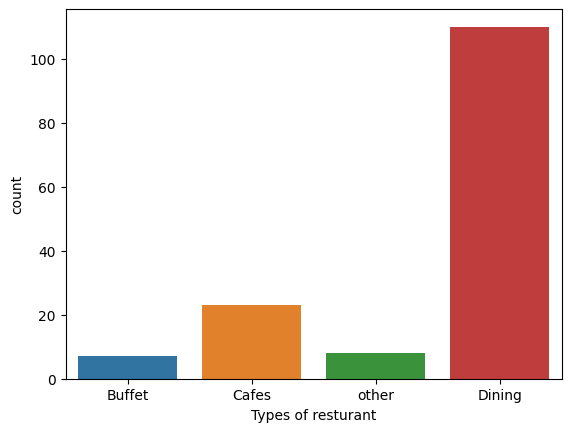

In [19]:
sns.countplot(x=df['listed_in(type)'], hue=df['listed_in(type)'])
plt.xlabel("Types of resturant")

### Votes by resturant type

Text(0, 0.5, 'Votes')

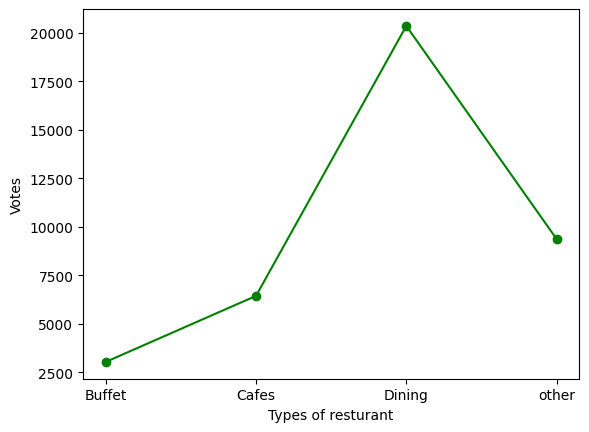

In [20]:
grp_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grp_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Types of resturant')
plt.ylabel('Votes')

### Online order vs Offline

<Axes: xlabel='online_order', ylabel='count'>

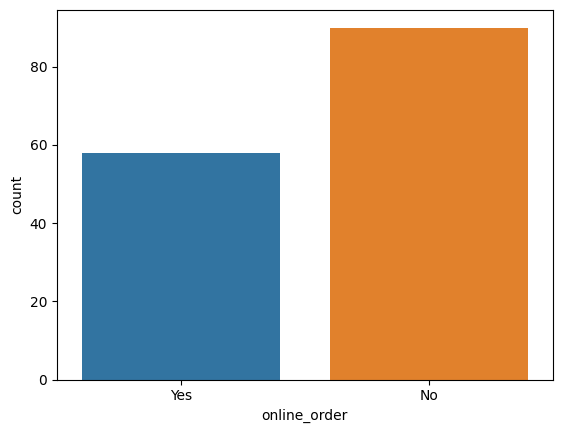

In [ ]:
sns.countplot(x=df['online_order'], hue=df['online_order'])

### Analyze rating

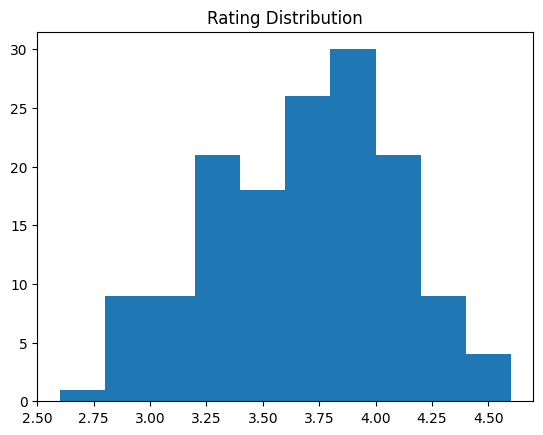

In [28]:
# Checking the distribution of rating from rate
plt.hist(df['rate'], bins=10)
plt.title('Rating Distribution')
plt.show()

### Aproximate cost for couples

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

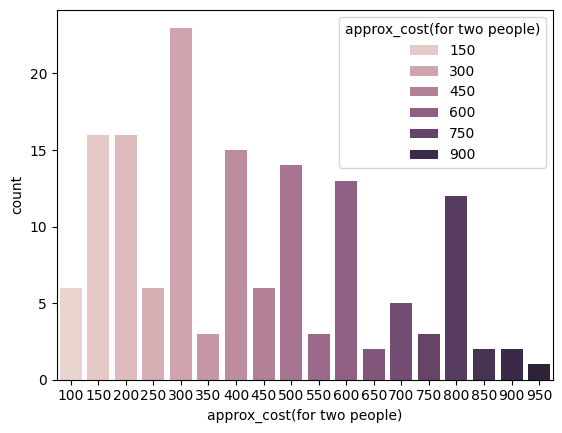

In [31]:
sns.countplot(x=df['approx_cost(for two people)'], hue=df['approx_cost(for two people)'])

### Order Mode Preferences by Resturant Type